#Practica Final:Evaluación y Optimización de Modelos de Regresión
#Tema 4 Inmobiliario
#Docente: José Gabriel Rodríguez Rivas
#Alumnos: Mario Alberto Quiñones Hernandez y Samuel Lozano Orona

#1 Importar librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.tree import plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from xgboost import XGBRegressor

#2 Cargar Dataset

In [3]:
#https://drive.google.com/file/d/1bdzrt4cgcWuP2y4-Lje5ruBMk6yG-Kcv/view?usp=sharing
file_id = "1bdzrt4cgcWuP2y4-Lje5ruBMk6yG-Kcv"

url = f"https://drive.google.com/uc?id={file_id}"

#cargar datos
df=pd.read_csv(url)

df.head()

,city,area,rooms,bathroom,parking spaces,floor,animal,furniture,hoa (R$),rent amount (R$),property tax (R$),fire insurance (R$),total (R$)
0,São Paulo,70,2,1,1,7,acept,furnished,2065,3300,211,42,5618
1,São Paulo,320,4,4,0,20,acept,not furnished,1200,4960,1750,63,7973
2,Porto Alegre,80,1,1,1,6,acept,not furnished,1000,2800,0,41,3841
3,Porto Alegre,51,2,1,0,2,acept,not furnished,270,1112,22,17,1421
4,São Paulo,25,1,1,0,1,not acept,not furnished,0,800,25,11,836


#3 Información general

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10692 entries, 0 to 10691
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   city                 10692 non-null  object
 1   area                 10692 non-null  int64 
 2   rooms                10692 non-null  int64 
 3   bathroom             10692 non-null  int64 
 4   parking spaces       10692 non-null  int64 
 5   floor                10692 non-null  object
 6   animal               10692 non-null  object
 7   furniture            10692 non-null  object
 8   hoa (R$)             10692 non-null  int64 
 9   rent amount (R$)     10692 non-null  int64 
 10  property tax (R$)    10692 non-null  int64 
 11  fire insurance (R$)  10692 non-null  int64 
 12  total (R$)           10692 non-null  int64 
dtypes: int64(9), object(4)
memory usage: 1.1+ MB


In [5]:
df.describe()

,area,rooms,bathroom,parking spaces,hoa (R$),rent amount (R$),property tax (R$),fire insurance (R$),total (R$)
count,10692.000000,10692.000000,10692.000000,10692.000000,1.069200e+04,10692.000000,10692.000000,10692.000000,1.069200e+04
mean,149.217920,2.506079,2.236813,1.609147,1.174022e+03,3896.247194,366.704358,53.300879,5.490487e+03
std,537.016942,1.171266,1.407198,1.589521,1.559231e+04,3408.545518,3107.832321,47.768031,1.648473e+04
min,11.000000,1.000000,1.000000,0.000000,0.000000e+00,450.000000,0.000000,3.000000,4.990000e+02
25%,56.000000,2.000000,1.000000,0.000000,1.700000e+02,1530.000000,38.000000,21.000000,2.061750e+03
50%,90.000000,2.000000,2.000000,1.000000,5.600000e+02,2661.000000,125.000000,36.000000,3.581500e+03
75%,182.000000,3.000000,3.000000,2.000000,1.237500e+03,5000.000000,375.000000,68.000000,6.768000e+03
max,46335.000000,13.000000,10.000000,12.000000,1.117000e+06,45000.000000,313700.000000,677.000000,1.120000e+06


#4 LIMPIEZA DEL DATASET
Eliminar columnas innecesarias

In [6]:
df = df.drop(columns=["city","floor"], errors="ignore")

Revisar valores nulos

In [7]:
df.isnull().sum()

,0
area,0
rooms,0
bathroom,0
parking spaces,0
animal,0
furniture,0
hoa (R$),0
rent amount (R$),0
property tax (R$),0
fire insurance (R$),0


Si existen:

In [8]:
df = df.dropna()

#Revisar duplicados

In [9]:
df.duplicated().sum()

np.int64(445)

Si hay duplicados:

In [10]:
df = df.drop_duplicates()

#Convertir variables categóricas

In [11]:
df = pd.get_dummies(df, drop_first=True)

#5 Eliminación de Outliers (IQR)

In [12]:
df_numeric = df.select_dtypes(include=[np.number])

Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)

IQR = Q3 - Q1

df = df[~((df_numeric < (Q1 - 1.5 * IQR)) |
          (df_numeric > (Q3 + 1.5 * IQR))).any(axis=1)]

#6 ANÁLISIS EXPLORATORIO DE DATOS
distribución de variables

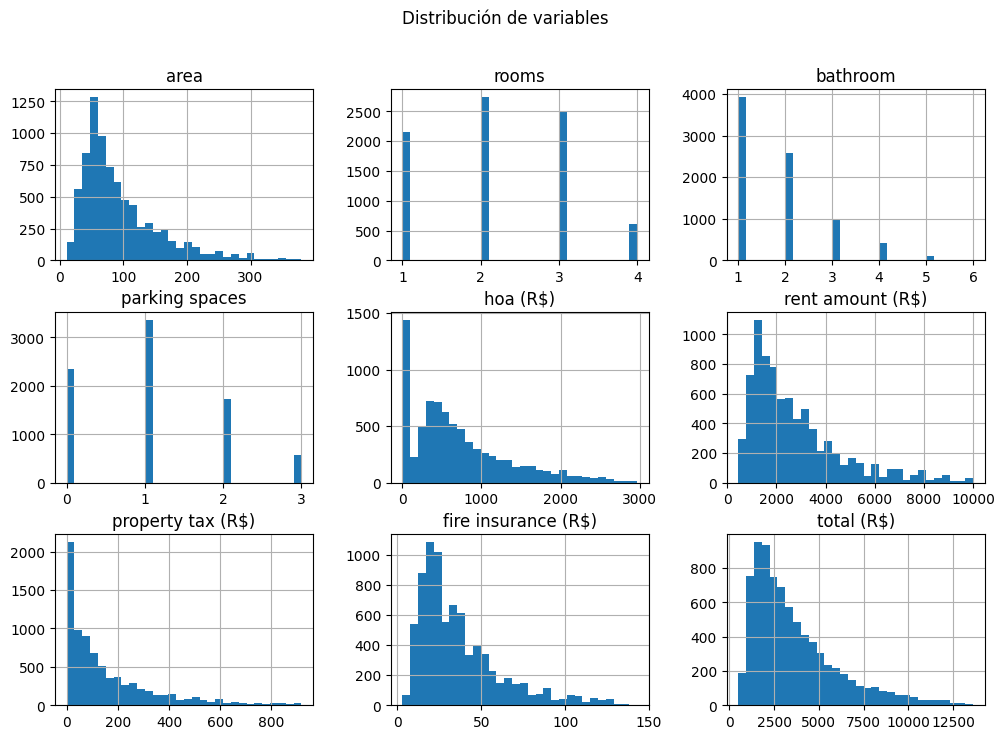

In [13]:
df.hist(figsize=(12,8), bins=30)
plt.suptitle("Distribución de variables")
plt.show()

#heatmap de correlación

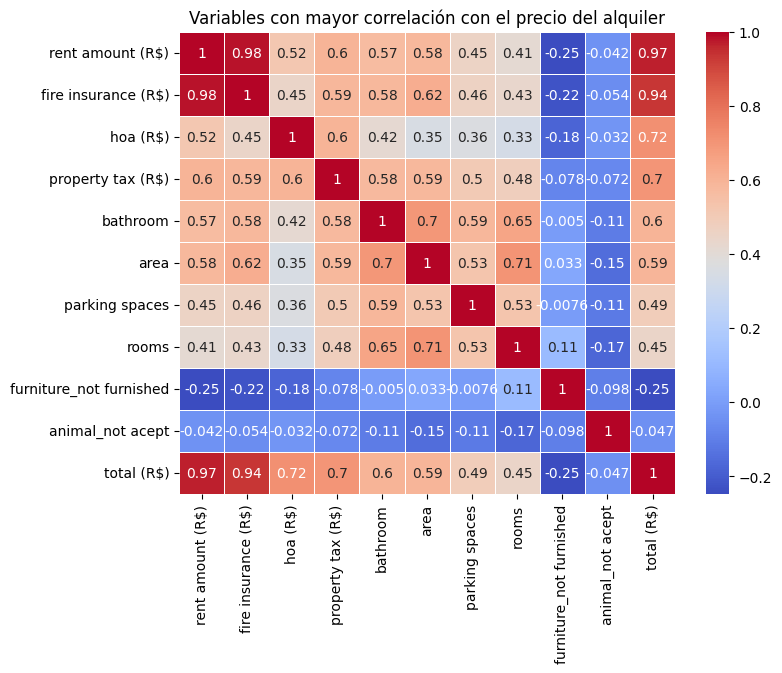

In [14]:
# calcular correlación con la variable objetivo
corr_target = df.corr()["total (R$)"].drop("total (R$)")

# seleccionar las 10 variables con mayor correlación
top_corr = corr_target.abs().sort_values(ascending=False).head(10)

# crear dataframe solo con esas variables
df_heatmap = df[top_corr.index.tolist() + ["total (R$)"]]

# matriz de correlación
corr_matrix = df_heatmap.corr()

# heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Variables con mayor correlación con el precio del alquiler")

plt.show()

#heatmap más claro

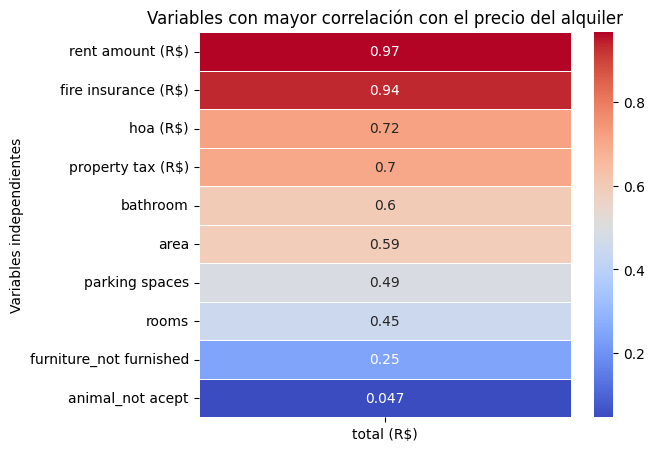

In [15]:
# calcular correlación con la variable objetivo
corr_target = df.corr(numeric_only=True)["total (R$)"]

# eliminar la propia variable objetivo
corr_target = corr_target.drop("total (R$)")

# seleccionar las 10 variables con mayor correlación
corr_target = corr_target.abs().sort_values(ascending=False).head(10)

# convertir a dataframe para el heatmap
corr_target = corr_target.to_frame()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr_target,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Variables con mayor correlación con el precio del alquiler")

plt.ylabel("Variables independientes")

plt.show()

#correlación con la variable objetivo

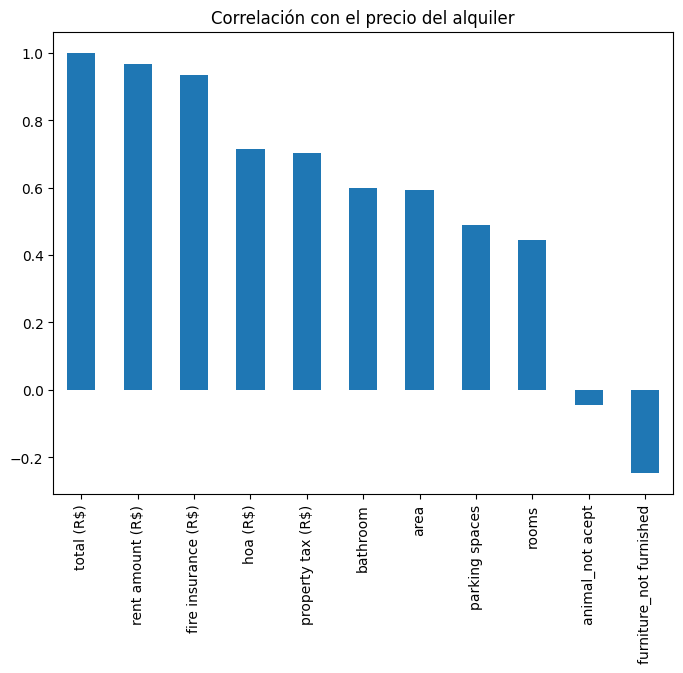

In [16]:
corr_target = df.corr()["total (R$)"].sort_values(ascending=False)

corr_target.plot(kind="bar", figsize=(8,6))

plt.title("Correlación con el precio del alquiler")

plt.show()

#scatter plots

#Área vs precio

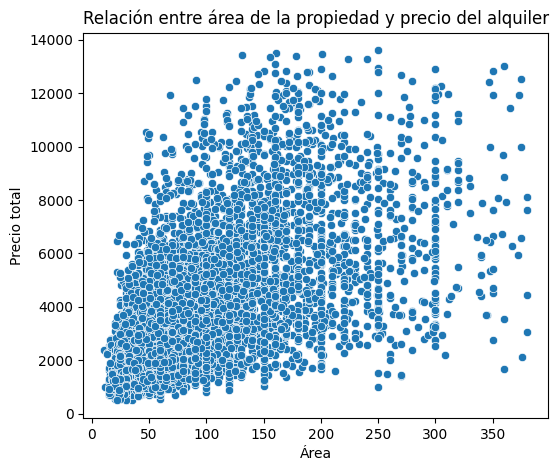

In [17]:
plt.figure(figsize=(6,5))

sns.scatterplot(x=df["area"], y=df["total (R$)"])

plt.title("Relación entre área de la propiedad y precio del alquiler")

plt.xlabel("Área")

plt.ylabel("Precio total")

plt.show()

#Habitaciones vs precio

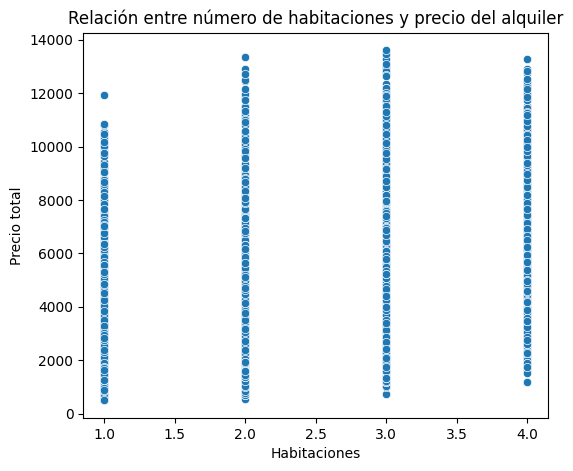

In [18]:
plt.figure(figsize=(6,5))

sns.scatterplot(x=df["rooms"], y=df["total (R$)"])

plt.title("Relación entre número de habitaciones y precio del alquiler")

plt.xlabel("Habitaciones")

plt.ylabel("Precio total")

plt.show()

#Baños vs precio

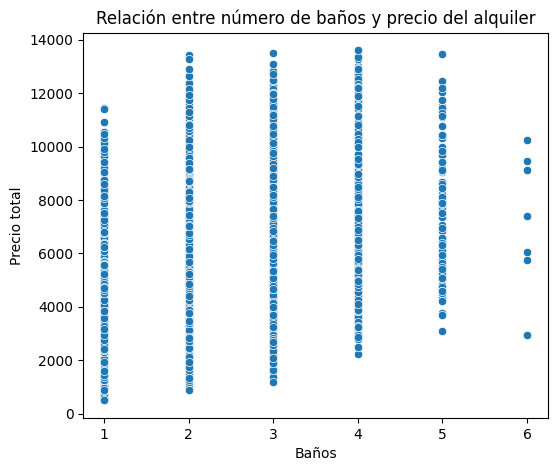

In [19]:
plt.figure(figsize=(6,5))

sns.scatterplot(x=df["bathroom"], y=df["total (R$)"])

plt.title("Relación entre número de baños y precio del alquiler")

plt.xlabel("Baños")

plt.ylabel("Precio total")

plt.show()

#7 PREPARACIÓN DE DATOS

In [20]:
X = df.drop("total (R$)", axis=1)

y = df["total (R$)"]

#división 80/20

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#8 FUNCIÓN PARA EVALUAR MODELOS

In [22]:
def evaluar_modelo(modelo, X_train, X_test):

    inicio = time.time()

    modelo.fit(X_train, y_train)

    fin = time.time()

    pred = modelo.predict(X_test)

    r2 = r2_score(y_test, pred)

    mae = mean_absolute_error(y_test, pred)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    tiempo = (fin - inicio) * 1000

    return r2, mae, rmse, tiempo

#FASE II
#MODELOS BASELINE

#Regresión Lineal

In [23]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# predicciones
y_pred_lr = lr_model.predict(X_test)

# métricas
#mae_lr = mean_absolute_error(y_test, y_pred_lr)
#rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
#r2_lr = r2_score(y_test, y_pred_lr)
#t_lr = evaluar_modelo(lr_model, X_train, X_test)
r2_lr, mae_lr, rmse_lr, t_lr = evaluar_modelo(lr_model, X_train, X_test)


print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

MAE: 0.5665306790926946
RMSE: 9.915690948169805
R2: 0.9999829050355773


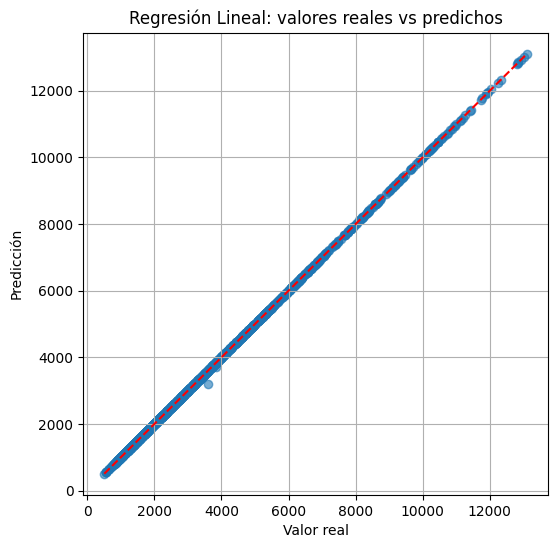

In [24]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_lr, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Valor real")
plt.ylabel("Predicción")

plt.title("Regresión Lineal: valores reales vs predichos")

plt.grid(True)

plt.show()

#Árbol de Decisión

In [25]:
modelo_dt = DecisionTreeRegressor()

r2_dt, mae_dt, rmse_dt, t_dt = evaluar_modelo(modelo_dt, X_train, X_test)

In [26]:

tree_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

In [27]:
mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print("MAE:", mae_tree)
print("RMSE:", rmse_tree)
print("R2:", r2_tree)

MAE: 284.7827964082181
RMSE: 369.766612563379
R2: 0.9762273483633401


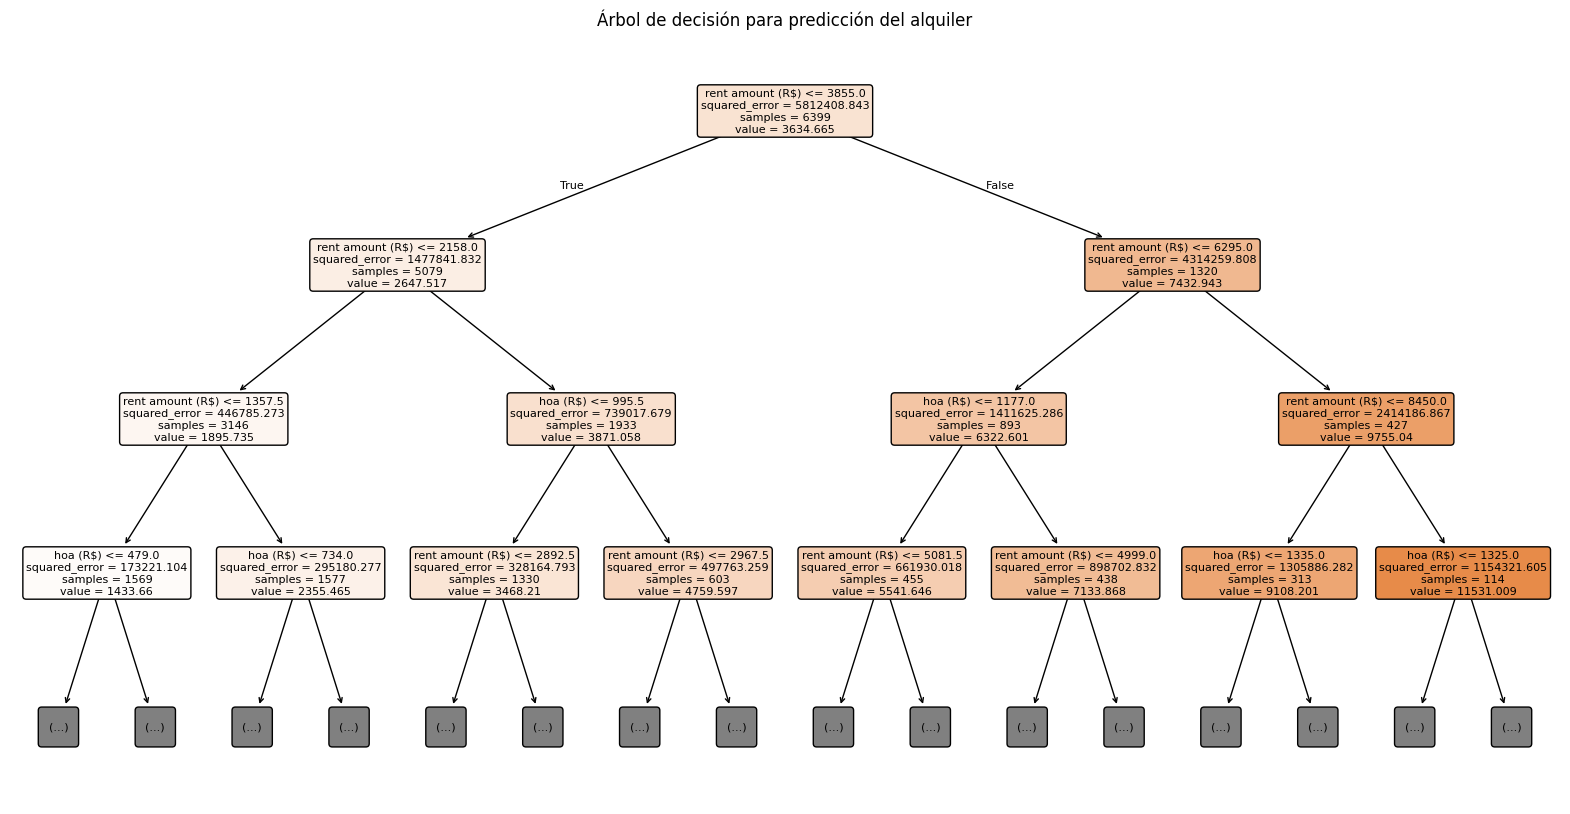

In [28]:
plt.figure(figsize=(20,10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)

plt.title("Árbol de decisión para predicción del alquiler")

plt.show()

#Random Forest

In [29]:
modelo_rf = RandomForestRegressor()

r2_rf, mae_rf, rmse_rf, t_rf = evaluar_modelo(modelo_rf, X_train, X_test)

In [30]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [31]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

MAE: 42.94380625000001
RMSE: 78.85156321017043
R2: 0.9989189572914995


#SVR con escalado

In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

inicio = time.time()

modelo_svr = SVR()

modelo_svr.fit(X_train_scaled, y_train)

fin = time.time()

pred_svr = modelo_svr.predict(X_test_scaled)

r2_svr = r2_score(y_test, pred_svr)

mae_svr = mean_absolute_error(y_test, pred_svr)

rmse_svr = np.sqrt(mean_squared_error(y_test, pred_svr))

t_svr = (fin - inicio) * 1000

In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svr_model = SVR(kernel='rbf')

svr_model.fit(X_train_scaled, y_train)

y_pred_svr = svr_model.predict(X_test_scaled)

In [34]:
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

print("MAE:", mae_svr)
print("RMSE:", rmse_svr)
print("R2:", r2_svr)

MAE: 1373.5070478148964
RMSE: 2102.9896512890655
R2: 0.23105282112529357


#XGBoost

In [35]:
modelo_xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

r2_xgb, mae_xgb, rmse_xgb, t_xgb = evaluar_modelo(modelo_xgb, X_train, X_test)

In [36]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [37]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

MAE: 38.09299850463867
RMSE: 57.02039066134039
R2: 0.9994347095489502


<Figure size 800x600 with 0 Axes>

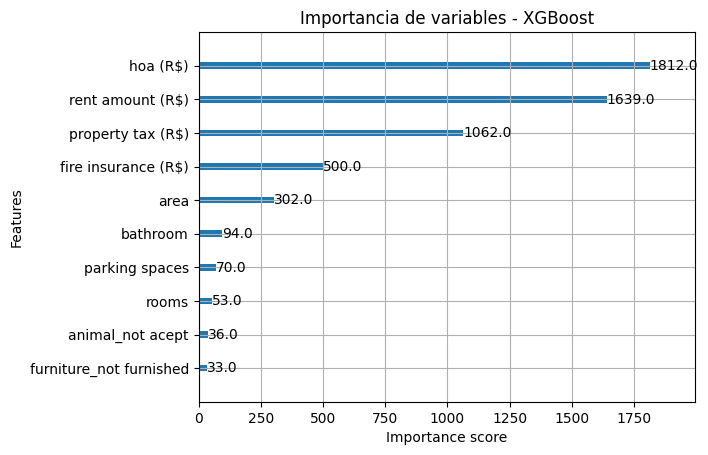

In [38]:
from xgboost import plot_importance

plt.figure(figsize=(8,6))

plot_importance(
    xgb_model,
    max_num_features=10
)

plt.title("Importancia de variables - XGBoost")

plt.show()

#TABLA COMPARATIVA

In [39]:
resultados = pd.DataFrame({
    "Algoritmo":[
        "Regresión Lineal",
        "Árbol de Decisión",
        "Random Forest",
        "SVR",
        "XGBoost"
    ],
    "R2":[r2_lr,r2_dt,r2_rf,r2_svr,r2_xgb],
    "MAE":[mae_lr,mae_dt,mae_rf,mae_svr,mae_xgb],
    "RMSE":[rmse_lr,rmse_dt,rmse_rf,rmse_svr,rmse_xgb],
    "Tiempo(ms)":[t_lr,t_dt,t_rf,t_svr,t_xgb]
})

resultados = resultados.round(4)
resultados = resultados.sort_values(by="R2", ascending=False)
resultados

,Algoritmo,R2,MAE,RMSE,Tiempo(ms)
0,Regresión Lineal,1.0000,0.5665,9.9157,4.2119
4,XGBoost,0.9994,38.0930,57.0204,226.1856
2,Random Forest,0.9989,42.9438,78.8516,3447.5164
1,Árbol de Decisión,0.9970,80.3644,130.9970,57.0655
3,SVR,0.2311,1373.5070,2102.9897,2069.6514


#Ranking

In [40]:
resultados = resultados.sort_values(by="R2", ascending=False)

resultados

,Algoritmo,R2,MAE,RMSE,Tiempo(ms)
0,Regresión Lineal,1.0000,0.5665,9.9157,4.2119
4,XGBoost,0.9994,38.0930,57.0204,226.1856
2,Random Forest,0.9989,42.9438,78.8516,3447.5164
1,Árbol de Decisión,0.9970,80.3644,130.9970,57.0655
3,SVR,0.2311,1373.5070,2102.9897,2069.6514


#gráfica comparativa

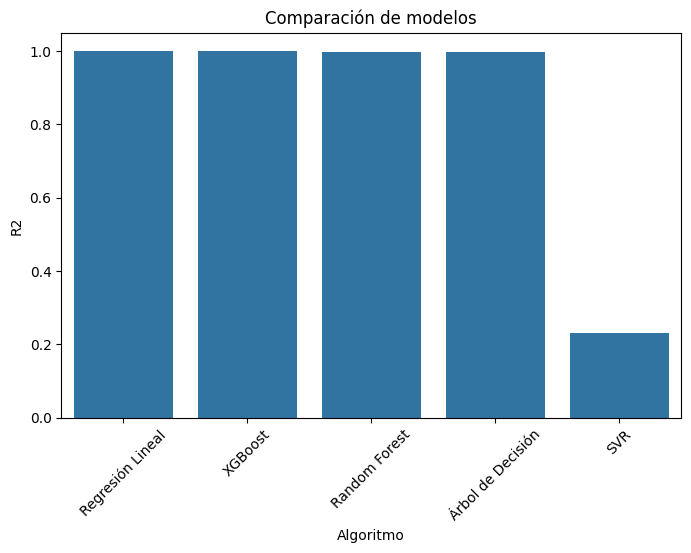

In [41]:
plt.figure(figsize=(8,5))

sns.barplot(x="Algoritmo", y="R2", data=resultados)

plt.xticks(rotation=45)

plt.title("Comparación de modelos")

plt.show()

#FASE III
#GRIDSEARCHCV

# **Consulta a IAG**
**Pregunta realizada a la IA:**

“Estamos trabajando con el dataset Brazil Houses - Rent Prediction y queremos predecir la variable total (R$). Ya entrenamos modelos de Regresión Lineal, Árbol de Decisión, Random Forest, SVR y XGBoost. ¿Qué hiperparámetros nos recomiendas ajustar con GridSearchCV para Random Forest y SVR, y qué transformaciones de datos serían convenientes?”


**Respuesta resumida de la IA:**

La IA sugirió que para Random Forest se probaran hiperparámetros como n_estimators, max_depth, min_samples_split y min_samples_leaf, ya que estos influyen directamente en la capacidad de generalización del modelo. Para SVR, recomendó ajustar C, gamma, epsilon y utilizar obligatoriamente escalado de datos con StandardScaler, debido a la sensibilidad de este algoritmo a la magnitud de las variables. Además, sugirió revisar si existen variables con relación demasiado directa con la variable objetivo, ya que eso podría generar fuga de información y métricas artificialmente altas.


**Decisión tomada por el equipo:**

Con base en estas sugerencias, se aplicó GridSearchCV sobre Random Forest y SVR para buscar configuraciones óptimas y comparar su desempeño contra los modelos baseline.

#optimización Random Forest

In [42]:
parametros_rf = {

"n_estimators":[100,200,300],

"max_depth":[None,10,20],

"min_samples_split":[2,5]

}

grid_rf = GridSearchCV(
RandomForestRegressor(),
parametros_rf,
cv=5,
scoring="r2"
)

grid_rf.fit(X_train, y_train)

mejor_rf = grid_rf.best_estimator_

In [43]:
# importancia de variables usando Random Forest
importancias = modelo_rf.feature_importances_

# nombres de variables
variables = X.columns

# dataframe con resultados
feature_importance = pd.DataFrame({
    "Variable": variables,
    "Importancia": importancias
})

# ordenar de mayor a menor
feature_importance = feature_importance.sort_values(
    by="Importancia",
    ascending=False
)

feature_importance.head(10)

,Variable,Importancia
5,rent amount (R$),0.925547
4,hoa (R$),0.070123
6,property tax (R$),0.002460
7,fire insurance (R$),0.001245
0,area,0.000283
2,bathroom,0.000103
3,parking spaces,0.000089
1,rooms,0.000073
9,furniture_not furnished,0.000044
8,animal_not acept,0.000033


/tmp/ipykernel_153/550841319.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


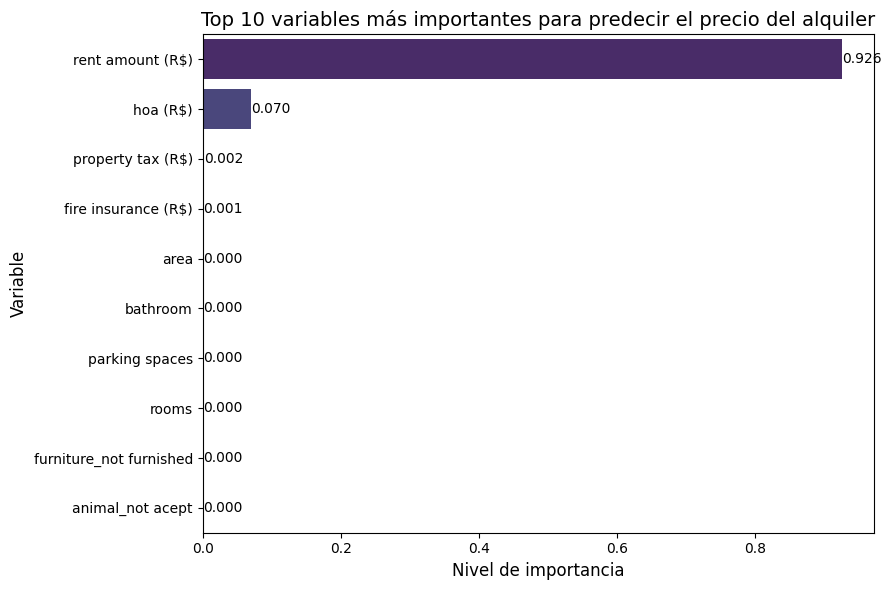

In [44]:
# seleccionar las 10 variables más importantes
top_features = feature_importance.head(10)

plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=top_features,
    x="Importancia",
    y="Variable",
    palette="viridis"
)

# mostrar valores en cada barra
for i in ax.containers:
    ax.bar_label(i, fmt="%.3f")

plt.title("Top 10 variables más importantes para predecir el precio del alquiler", fontsize=14)

plt.xlabel("Nivel de importancia", fontsize=12)

plt.ylabel("Variable", fontsize=12)

plt.tight_layout()

plt.show()

#evaluación modelo optimizado

In [45]:
pred_rf = mejor_rf.predict(X_test)

r2_rf_opt = r2_score(y_test, pred_rf)

mae_rf_opt = mean_absolute_error(y_test, pred_rf)

rmse_rf_opt = np.sqrt(mean_squared_error(y_test, pred_rf))

#optimización SVR

In [46]:
parametros_svr = {

"C":[0.1,1,10,100],

"gamma":["scale","auto",0.01,0.1],

"epsilon":[0.01,0.1,1]

}

grid_svr = GridSearchCV(
SVR(),
parametros_svr,
cv=5,
scoring="r2"
)

grid_svr.fit(X_train_scaled, y_train)

mejor_svr = grid_svr.best_estimator_

#tabla final

In [52]:
inicio = time.time()
mejor_rf.fit(X_train, y_train)
fin = time.time()

pred_rf_opt = mejor_rf.predict(X_test)

r2_rf_opt = r2_score(y_test, pred_rf_opt)
mae_rf_opt = mean_absolute_error(y_test, pred_rf_opt)
rmse_rf_opt = np.sqrt(mean_squared_error(y_test, pred_rf_opt))
t_rf_opt = (fin - inicio) * 1000

In [50]:
inicio = time.time()
mejor_svr.fit(X_train_scaled, y_train)
fin = time.time()

pred_svr_opt = mejor_svr.predict(X_test_scaled)

r2_svr_opt = r2_score(y_test, pred_svr_opt)
mae_svr_opt = mean_absolute_error(y_test, pred_svr_opt)
rmse_svr_opt = np.sqrt(mean_squared_error(y_test, pred_svr_opt))
t_svr_opt = (fin - inicio) * 1000

In [53]:
tabla_final = pd.DataFrame({
    "Modelo":[
        "Random Forest Optimizado",
        "SVR Optimizado"
    ],
    "R2":[
        r2_rf_opt,
        r2_svr_opt
    ],
    "MAE":[
        mae_rf_opt,
        mae_svr_opt
    ],
    "RMSE":[
        rmse_rf_opt,
        rmse_svr_opt
    ],
    "Tiempo(ms)":[
        t_rf_opt,
        t_svr_opt
    ]
})

tabla_final = tabla_final.round(4)
tabla_final

,Modelo,R2,MAE,RMSE,Tiempo(ms)
0,Random Forest Optimizado,0.9990,42.1755,77.5358,17604.0447
1,SVR Optimizado,0.9953,80.1466,165.0712,8070.7588


#gráfica real vs predicción

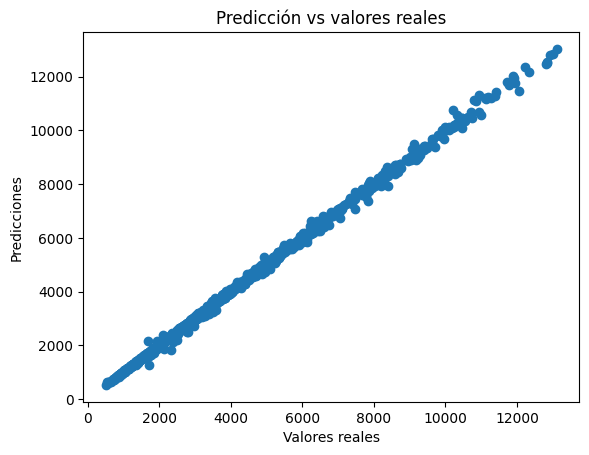

In [48]:
plt.scatter(y_test, pred_rf)

plt.xlabel("Valores reales")

plt.ylabel("Predicciones")

plt.title("Predicción vs valores reales")

plt.show()

#Grafica mas precisa

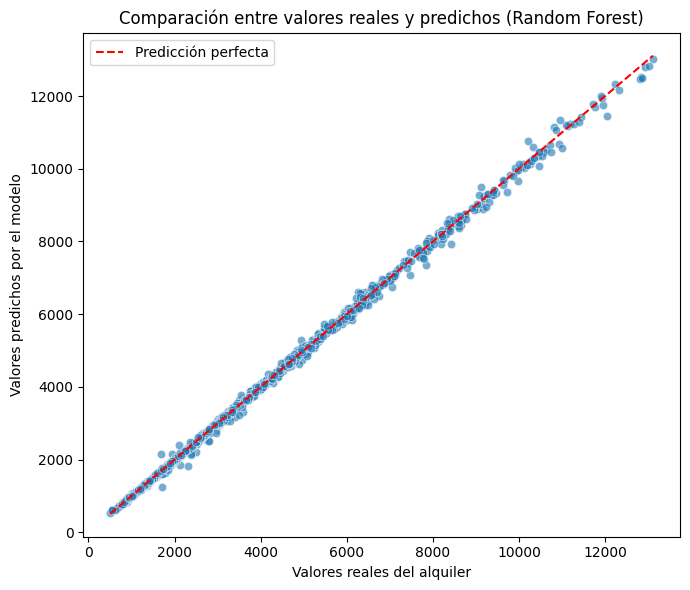

In [49]:
plt.figure(figsize=(7,6))

sns.scatterplot(
    x=y_test,
    y=pred_rf,
    alpha=0.6
)

# línea ideal de predicción perfecta
min_val = min(y_test.min(), pred_rf.min())
max_val = max(y_test.max(), pred_rf.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    label="Predicción perfecta"
)

plt.xlabel("Valores reales del alquiler")

plt.ylabel("Valores predichos por el modelo")

plt.title("Comparación entre valores reales y predichos (Random Forest)")

plt.legend()

plt.tight_layout()

plt.show()

# **Conclusión Final**

Después de comparar los cinco modelos de regresión, se observó que el mejor desempeño lo obtuvo la Regresión Lineal, ya que presentó el mayor valor de R² y los menores errores MAE y RMSE. Esto indica que fue el modelo que mejor se adaptó al comportamiento del dataset utilizado. También se encontró que XGBoost y Random Forest ofrecieron resultados muy buenos, mientras que SVR fue el modelo con menor precisión en este problema.

El uso de la IAG fue de gran ayuda para sugerir hiperparámetros y orientar la optimización con GridSearchCV, ya que permitió seleccionar configuraciones iniciales razonables para los modelos más prometedores. Gracias a esto, el proceso de ajuste fue más rápido y mejor enfocado.

Sobre la relación entre tiempo de ejecución y precisión, se observó que los modelos más complejos suelen requerir más tiempo, pero no siempre eso implica que sean los mejores. En este caso, la Regresión Lineal logró excelentes resultados con un costo computacional relativamente bajo, mientras que otros modelos más complejos no necesariamente superaron ese rendimiento.

En conclusión, la Regresión Lineal fue el modelo ganador para este dataset, aunque también se identificó que algunas variables tienen una relación muy directa con la variable objetivo, por lo que esto pudo influir en los resultados obtenidos.